# Movie Revenue Analysis Project
**Author:** Ankita Panwar  
**Course:** MBA Business Analytics & Finance(2024-26) 
**Tools Used:** Python, Pandas, Seaborn, Matplotlib  
**Date:** 28-03-2026 

# This project aims to analyze the factors influencing movie box office performance.
# The dataset includes various attributes such as budget, gross revenue, ratings, votes, genre, and production company.

# The objective is to identify key drivers of movie success by performing:
# - Data cleaning and preprocessing
# - Exploratory data analysis (EDA)
# - Data visualization using plots
# - Correlation analysis
#
# Key focus areas include understanding the impact of budget, audience engagement,and ratings on gross revenue.


In [8]:
# First let's import the packages we will use in this project
# You can do this all now or as you need them
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)

pd.options.mode.chained_assignment = None



# Now we need to read in the data
df = pd.read_csv("movies.csv")

In [10]:
# Let's look at the data by choosing only top 5 
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [12]:
# We need to see if we have any missing data
# Let's loop through the data and see if there is anything missing

for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

name - 0%
rating - 1%
genre - 0%
year - 0%
released - 0%
score - 0%
votes - 0%
director - 0%
writer - 0%
star - 0%
country - 0%
budget - 28%
gross - 2%
company - 0%
runtime - 0%


In [14]:
# Data Types for our columns

print(df.dtypes)

name         object
rating       object
genre        object
year          int64
released     object
score       float64
votes       float64
director     object
writer       object
star         object
country      object
budget      float64
gross       float64
company      object
runtime     float64
dtype: object


In [16]:
# Order our Data a little bit to see
df.sort_values(by= ['gross'],inplace=False ,ascending = False)


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000.0,2.847246e+09,Twentieth Century Fox,162.0
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000.0,2.797501e+09,Marvel Studios,181.0
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000.0,2.201647e+09,Twentieth Century Fox,194.0
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000.0,2.069522e+09,Lucasfilm,138.0
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000.0,2.048360e+09,Marvel Studios,149.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,"October 23, 2020 (United States)",3.1,18.0,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000.0,NaN,NaN,90.0
7664,Dream Round,NaN,Comedy,2020,"February 7, 2020 (United States)",4.7,36.0,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,NaN,NaN,Cactus Blue Entertainment,90.0
7665,Saving Mbango,NaN,Drama,2020,"April 27, 2020 (Cameroon)",5.7,29.0,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750.0,NaN,Embi Productions,NaN
7666,It's Just Us,NaN,Drama,2020,"October 1, 2020 (United States)",NaN,NaN,James Randall,James Randall,Christina Roz,United States,15000.0,NaN,NaN,120.0


In [18]:
# Removing records with missing values in 'gross' and 'budget'
# to maintain data quality and ensure reliable analysis of financial performance
df = df.dropna(subset=['gross', 'budget'])

In [20]:
# Displaying dataset dimensions (rows and columns) to verify data size after cleaning and preprocessing
print(df.shape)

(5436, 15)


In [22]:
# Verifying that there are no missing values in key financial columns ('gross' and 'budget')
# to ensure data is ready for analysis
df[['gross', 'budget']].isnull().sum()

gross     0
budget    0
dtype: int64

In [24]:
# Identifying duplicate records in the dataset to ensure data integrity and avoid redundancy
df.duplicated().sum()

0

In [28]:
# Identifying distinct production companies to understand the diversity of the dataset
df['company'].drop_duplicates()

0                              Warner Bros.
1                         Columbia Pictures
2                                 Lucasfilm
3                        Paramount Pictures
4                            Orion Pictures
                       ...                 
7615               Growing Tree Productions
7616                 Hicktown Entertainment
7645                Clubhouse Pictures (II)
7651                   20th Century Studios
7652    Beijing Diqi Yinxiang Entertainment
Name: company, Length: 1482, dtype: object

In [26]:
# Identifying unique production companies and sorting them
# to explore the diversity and structure of the movie industry dataset
df['company'].drop_duplicates().sort_values(ascending=False)

7129                                thefyzz
5664                            micro_scope
4007                               i5 Films
6793                             i am OTHER
6420                                   erbp
                       ...                 
2929                          1492 Pictures
3024                        .406 Production
7525    "Weathering With You" Film Partners
4345        "DIA" Productions GmbH & Co. KG
633                                     NaN
Name: company, Length: 1482, dtype: object

In [30]:
#Top companies by revenue
df.groupby('company')['gross'].sum().sort_values(ascending=False).head(10)

company
Warner Bros.             5.477320e+10
Universal Pictures       5.124111e+10
Columbia Pictures        4.235643e+10
Paramount Pictures       4.002170e+10
Twentieth Century Fox    3.954257e+10
Walt Disney Pictures     3.583365e+10
New Line Cinema          1.962879e+10
Marvel Studios           1.506559e+10
DreamWorks Animation     1.187361e+10
Dreamworks Pictures      1.159381e+10
Name: gross, dtype: float64

In [32]:
#Top companies by number of movies
df['company'].value_counts().head(10)

company
Universal Pictures           330
Columbia Pictures            302
Warner Bros.                 299
Paramount Pictures           279
Twentieth Century Fox        209
New Line Cinema              156
Walt Disney Pictures         107
Touchstone Pictures          105
Metro-Goldwyn-Mayer (MGM)     99
Dreamworks Pictures           75
Name: count, dtype: int64

In [34]:
#Top companies by average performance
df.groupby('company')['gross'].mean().sort_values(ascending=False).head(10)

company
Marvel Studios                                                   1.255466e+09
Illumination Entertainment                                       1.097122e+09
Fairview Entertainment                                           9.665549e+08
B24                                                              8.806815e+08
Avi Arad Productions                                             8.560852e+08
Chris Morgan Productions                                         7.590569e+08
Jolie Pas                                                        7.584118e+08
Lucasfilm                                                        7.185352e+08
Marvel Entertainment                                             7.144215e+08
Beijing Dengfeng International Culture Communications Company    6.999925e+08
Name: gross, dtype: float64

In [36]:
# Order our Data a little bit to see
df =df.sort_values(by= ['gross'],inplace=False ,ascending = False)
df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000.0,2.847246e+09,Twentieth Century Fox,162.0
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000.0,2.797501e+09,Marvel Studios,181.0
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000.0,2.201647e+09,Twentieth Century Fox,194.0
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000.0,2.069522e+09,Lucasfilm,138.0
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000.0,2.048360e+09,Marvel Studios,149.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2434,Philadelphia Experiment II,PG-13,Action,1993,"June 4, 1994 (South Korea)",4.5,1900.0,Stephen Cornwell,Wallace C. Bennett,Brad Johnson,United States,5000000.0,2.970000e+03,Trimark Pictures,97.0
3681,Ginger Snaps,Not Rated,Drama,2000,"May 11, 2001 (Canada)",6.8,43000.0,John Fawcett,Karen Walton,Emily Perkins,Canada,5000000.0,2.554000e+03,Copperheart Entertainment,108.0
272,Parasite,R,Horror,1982,"March 12, 1982 (United States)",3.9,2300.0,Charles Band,Alan J. Adler,Robert Glaudini,United States,800000.0,2.270000e+03,Embassy Pictures,85.0
2417,Madadayo,NaN,Drama,1993,"April 17, 1993 (Japan)",7.3,5100.0,Akira Kurosawa,Ishirô Honda,Tatsuo Matsumura,Japan,11900000.0,5.960000e+02,DENTSU Music And Entertainment,134.0


In [38]:
# Looking at the top 15 compaies by gross revenue
# Calculating total gross revenue for each company and selecting top 15 companies
# to identify the highest earning production companies

CompanyGrossSum = df.groupby('company')[["gross"]].sum()

CompanyGrossSumSorted = CompanyGrossSum.sort_values('gross', ascending = False)[:15]

CompanyGrossSumSorted = CompanyGrossSumSorted['gross'].astype('int64') 

CompanyGrossSumSorted

company
Warner Bros.                 54773202654
Universal Pictures           51241105418
Columbia Pictures            42356430218
Paramount Pictures           40021704691
Twentieth Century Fox        39542573303
Walt Disney Pictures         35833650748
New Line Cinema              19628786232
Marvel Studios               15065592411
DreamWorks Animation         11873612858
Dreamworks Pictures          11593807697
Touchstone Pictures          10664679494
Metro-Goldwyn-Mayer (MGM)     8937010092
Summit Entertainment          8318570396
Pixar Animation Studios       7886344526
Fox 2000 Pictures             7243673721
Name: gross, dtype: int64

In [40]:
# Creating a new 'Year' column by extracting the release year from the 'released' field,
# enabling analysis of movie trends and performance over time
df['Year'] = df['released'].astype(str).str[:4]
df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,Year
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000.0,2.847246e+09,Twentieth Century Fox,162.0,Dece
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000.0,2.797501e+09,Marvel Studios,181.0,Apri
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000.0,2.201647e+09,Twentieth Century Fox,194.0,Dece
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000.0,2.069522e+09,Lucasfilm,138.0,Dece
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000.0,2.048360e+09,Marvel Studios,149.0,Apri
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2434,Philadelphia Experiment II,PG-13,Action,1993,"June 4, 1994 (South Korea)",4.5,1900.0,Stephen Cornwell,Wallace C. Bennett,Brad Johnson,United States,5000000.0,2.970000e+03,Trimark Pictures,97.0,June
3681,Ginger Snaps,Not Rated,Drama,2000,"May 11, 2001 (Canada)",6.8,43000.0,John Fawcett,Karen Walton,Emily Perkins,Canada,5000000.0,2.554000e+03,Copperheart Entertainment,108.0,May
272,Parasite,R,Horror,1982,"March 12, 1982 (United States)",3.9,2300.0,Charles Band,Alan J. Adler,Robert Glaudini,United States,800000.0,2.270000e+03,Embassy Pictures,85.0,Marc
2417,Madadayo,NaN,Drama,1993,"April 17, 1993 (Japan)",7.3,5100.0,Akira Kurosawa,Ishirô Honda,Tatsuo Matsumura,Japan,11900000.0,5.960000e+02,DENTSU Music And Entertainment,134.0,Apri


In [42]:
# Aggregating gross revenue by company and year to examine how different production companies
# perform over time and identify trends in their yearly box office earnings

df.groupby(['company', 'year'])[["gross"]].sum()

gross
company                             year             
"DIA" Productions GmbH & Co. KG     2003   44350926.0
"Weathering With You" Film Partners 2019  193457467.0
.406 Production                     1996      10580.0
1492 Pictures                       1996  129832389.0
                                    1999   87423861.0
...                                               ...
erbp                                2013     587174.0
i am OTHER                          2015   17986781.0
i5 Films                            2001   10031529.0
micro_scope                         2010    7099598.0
thefyzz                             2017   62198461.0

[2998 rows x 1 columns]

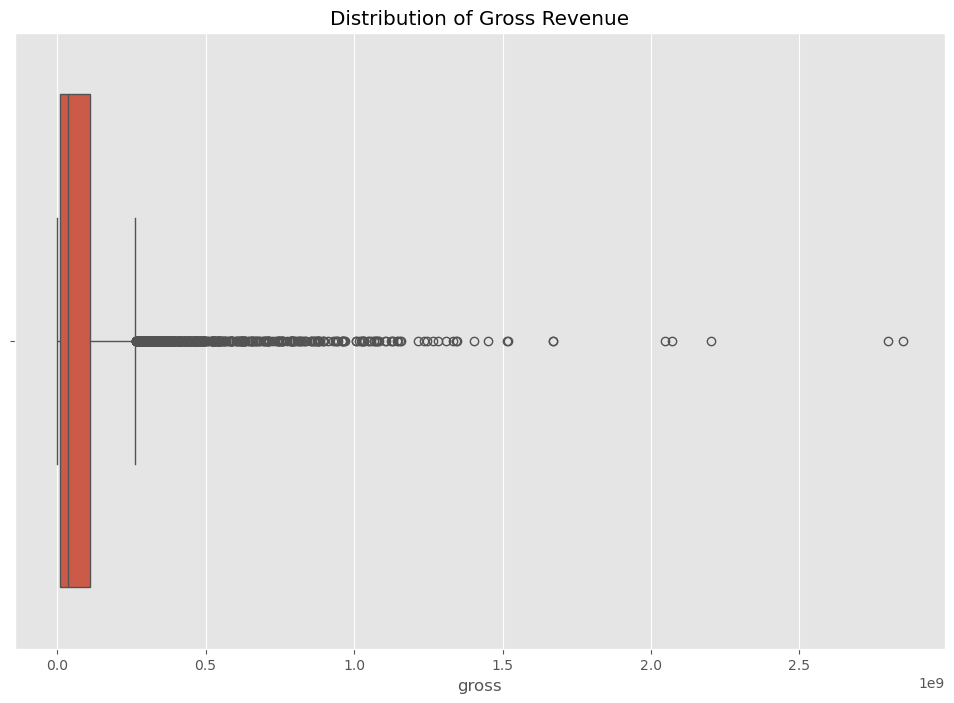

In [45]:
#Box Plot (Gross)
# The box plot shows that gross revenue is highly right-skewed, 
# with most movies earning lower revenue and a few blockbuster films acting as outliers.
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['gross'])
plt.title('Distribution of Gross Revenue')
plt.show()

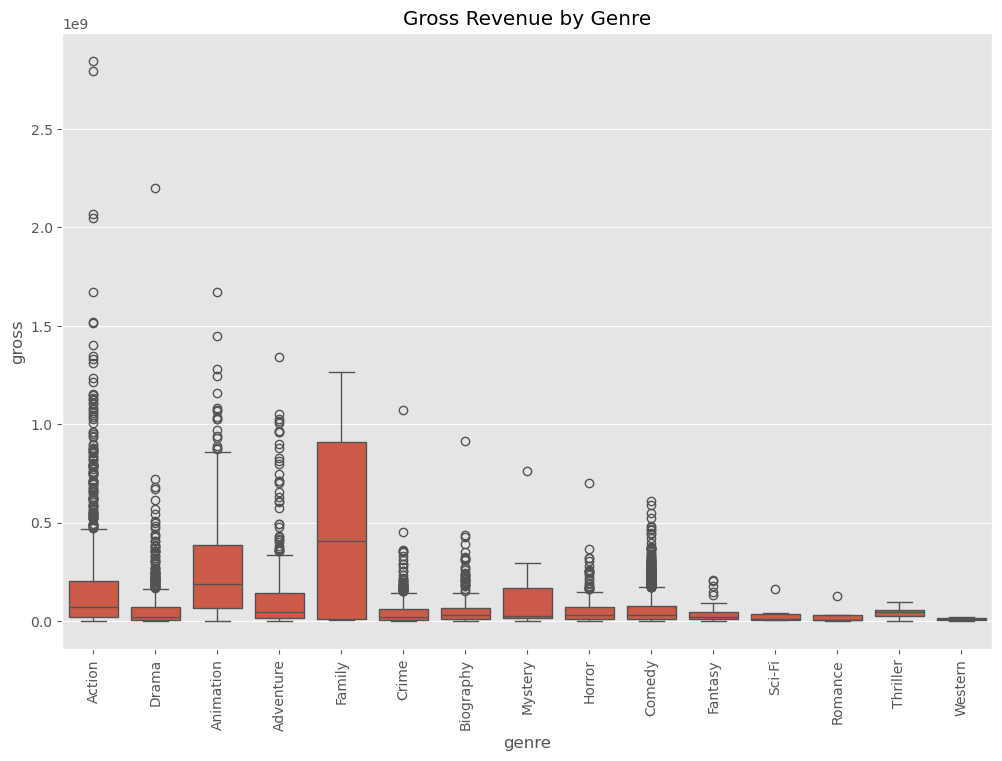

In [47]:
#Boxplot by Genre
# The box plot shows that genres like Action, Adventure, and Family tend to generate higher revenue.
# However, most movies across all genres earn relatively lower revenue, with a few blockbuster movies acting as outliers.
sns.boxplot(x='genre', y='gross', data=df)
plt.xticks(rotation=90)
plt.title('Gross Revenue by Genre')
plt.show()

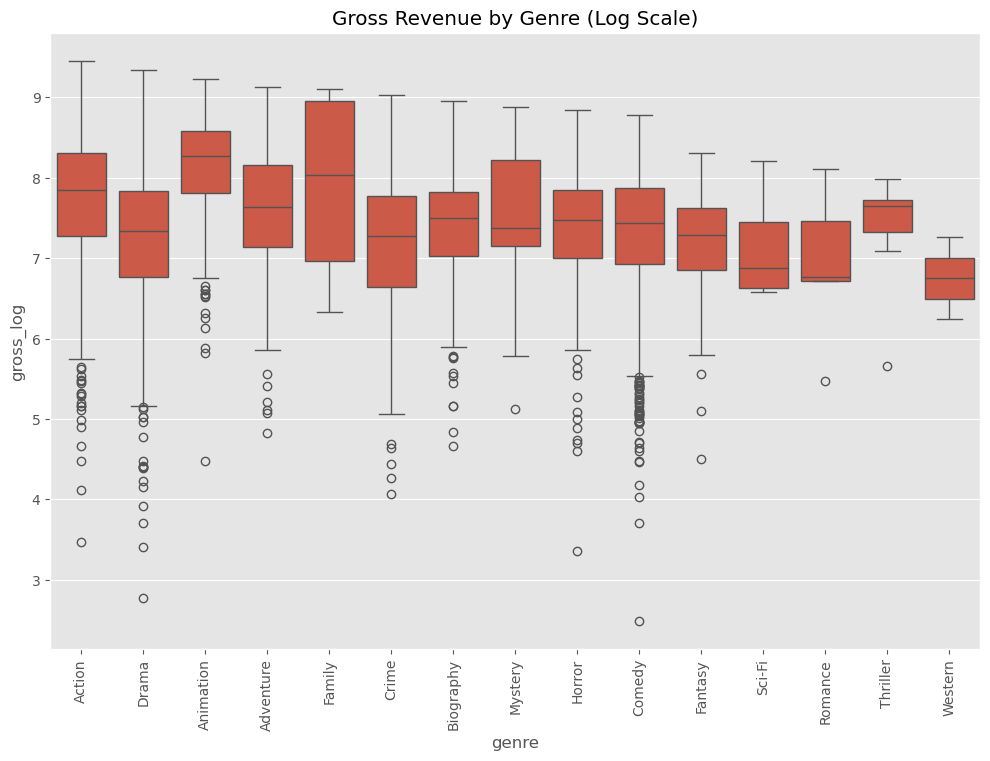

In [49]:
# Visualizing gross revenue across different genres using log transformation to reduce skewness
import numpy as np
df['gross_log'] = np.log10(df['gross'])

sns.boxplot(x='genre', y='gross_log', data=df)
plt.xticks(rotation=90)
plt.title('Gross Revenue by Genre (Log Scale)')
plt.show()

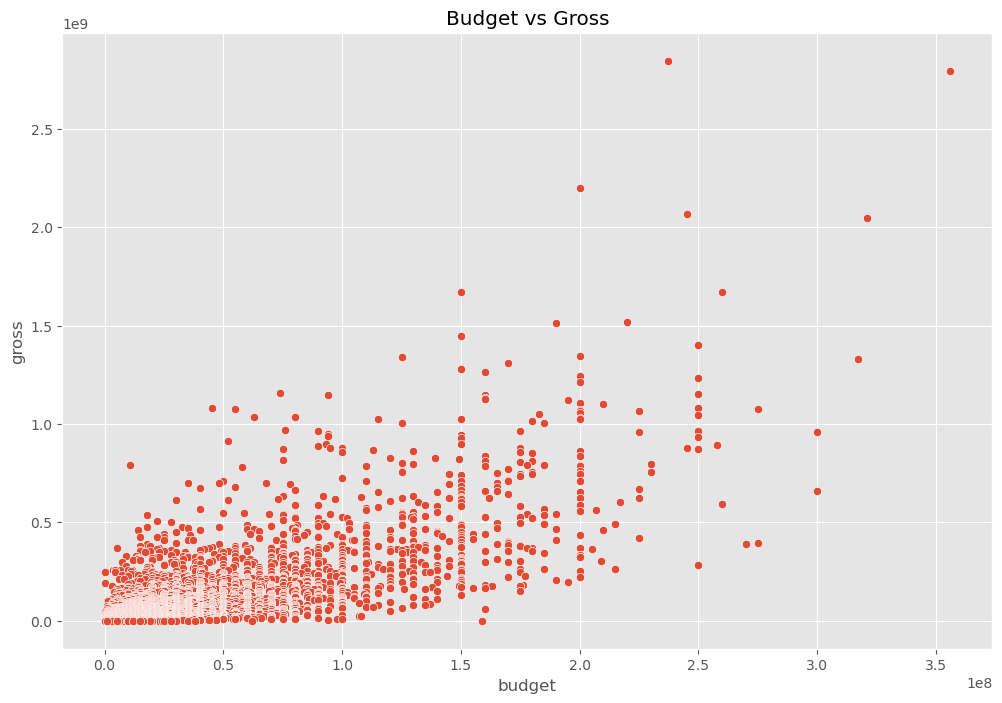

In [51]:
# Scatter plot to examine how movie budget influences gross revenue,
# helping identify trends and patterns in movie performance
sns.scatterplot(x='budget', y='gross', data=df)
plt.title('Budget vs Gross')
plt.show()

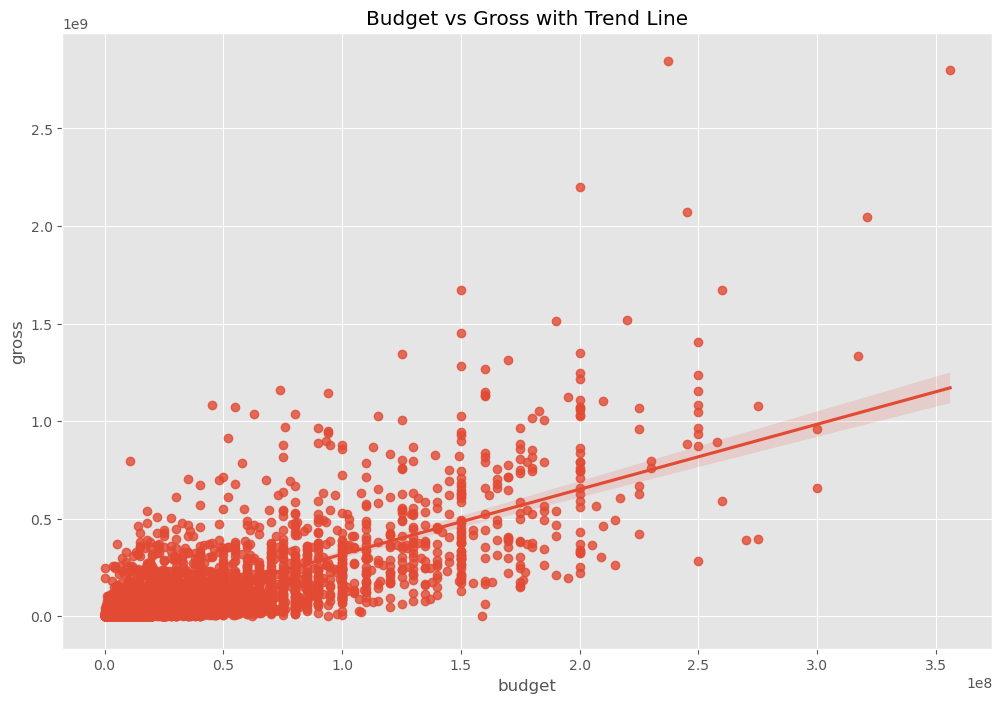

In [53]:
# Visualizing the relationship between movie budget and gross revenue with a trend line
# to understand overall direction and pattern
sns.regplot(x='budget', y='gross', data=df)
plt.title('Budget vs Gross with Trend Line')
plt.show()

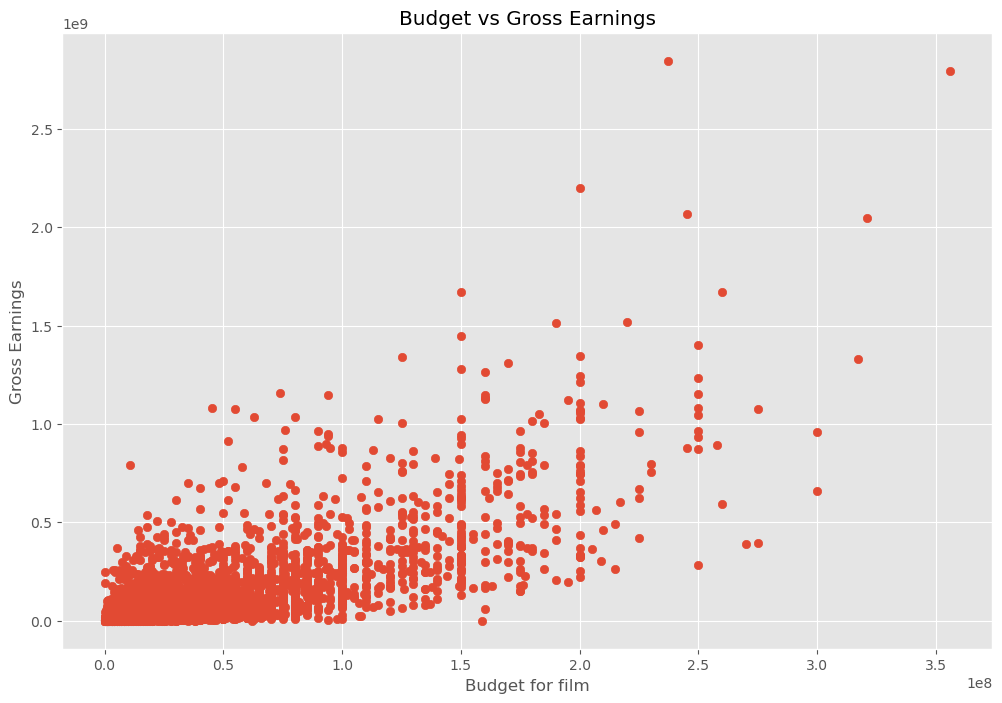

In [59]:
#scatter plot with budget vs gross
# The scatter plot shows a positive relationship between movie budget and gross earnings,
# indicating that higher budget films generally generate higher revenue.
# However, the spread of data points suggests that budget alone does not determine success,
# and other factors like audience popularity and marketing also play a role
plt.scatter(x=df['budget'],y=df['gross'])
plt.title('Budget vs Gross Earnings')
plt.xlabel('Budget for film')
plt.ylabel('Gross Earnings')
plt.show()

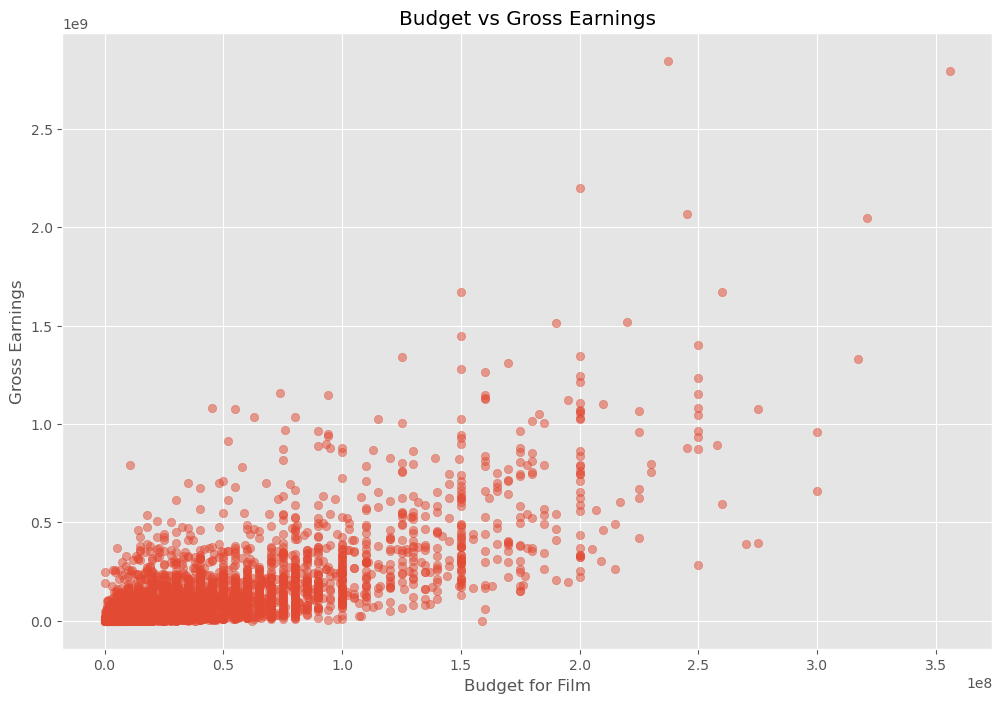

In [57]:
# Visualizing the impact of movie budget on gross earnings,
# where budget is treated as the independent variable (x-axis)
# and gross as the dependent variable (y-axis)
plt.scatter(x=df['budget'], y=df['gross'], alpha=0.5)
plt.title('Budget vs Gross Earnings')
plt.xlabel('Budget for Film')   
plt.ylabel('Gross Earnings')    
plt.show()

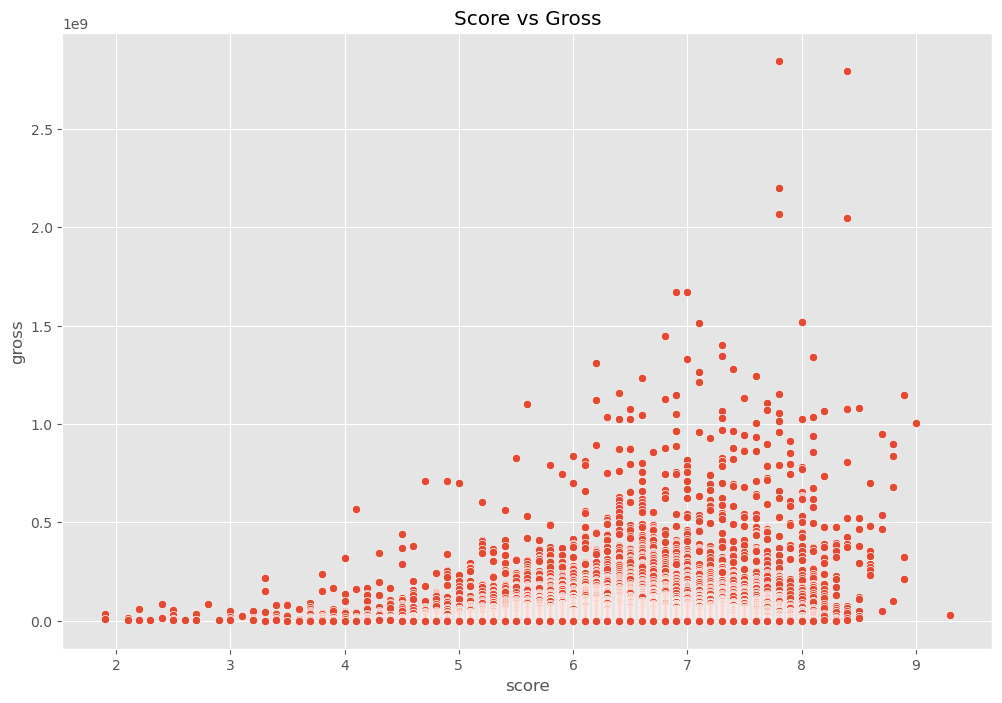

In [61]:
# Analyzing how movie ratings (score) relate to gross revenue using a scatter plot
sns.scatterplot(x='score', y='gross', data=df)
plt.title('Score vs Gross')
plt.show()

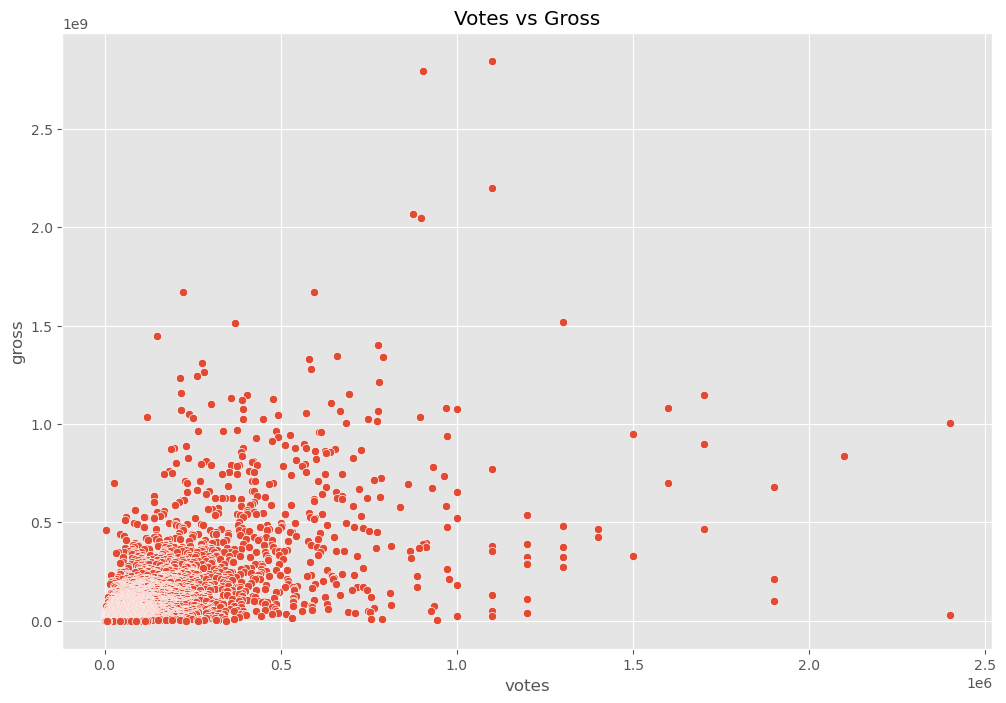

In [63]:
# Analyzing the relationship between audience votes and gross revenue using a scatter plot
sns.scatterplot(x='votes', y='gross', data=df)
plt.title('Votes vs Gross')
plt.show()

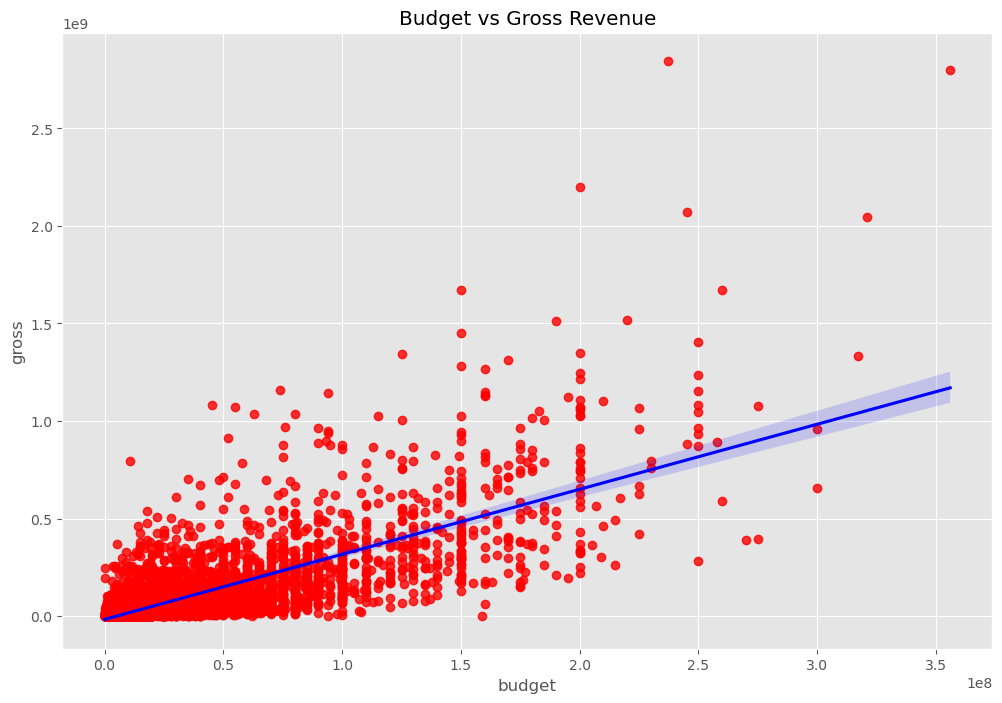

In [65]:
# The regplot visualizes the relationship between budget and gross revenue,
# with red data points and a blue regression line indicating a positive trend.
# It shows that higher budget movies tend to generate higher earnings,
# although variability suggests other factors also influence performance
sns.regplot(x='budget', y='gross', data=df, scatter_kws={"color": "red"}, line_kws={"color":"blue"})
plt.title('Budget vs Gross Revenue')
plt.show()

In [67]:
#Correlations#
# Correlation analysis shows that budget has the strongest positive relationship with gross revenue,
# followed by votes (audience popularity). Score (ratings) has a weak relationship,
# indicating that higher-rated movies do not necessarily generate higher earnings
df.corr(numeric_only=True)


,year,score,votes,budget,gross,runtime,gross_log
year,1.000000,0.055174,0.205758,0.327781,0.274264,0.074203,0.315287
score,0.055174,1.000000,0.473809,0.071792,0.222143,0.414580,0.187402
votes,0.205758,0.473809,1.000000,0.440021,0.614904,0.352437,0.491013
budget,0.327781,0.071792,0.440021,1.000000,0.740395,0.318595,0.594431
gross,0.274264,0.222143,0.614904,0.740395,1.000000,0.275596,0.625394
runtime,0.074203,0.414580,0.352437,0.318595,0.275596,1.000000,0.248433
gross_log,0.315287,0.187402,0.491013,0.594431,0.625394,0.248433,1.000000


In [69]:
#“Pearson correlation measures linear relationships, while Spearman and Kendall measure rank-based relationships.
#In this analysis, Pearson was used as the data primarily exhibits linear trends.”
df.corr(method='pearson', numeric_only=True) # pearson, kendall, spearman

,year,score,votes,budget,gross,runtime,gross_log
year,1.000000,0.055174,0.205758,0.327781,0.274264,0.074203,0.315287
score,0.055174,1.000000,0.473809,0.071792,0.222143,0.414580,0.187402
votes,0.205758,0.473809,1.000000,0.440021,0.614904,0.352437,0.491013
budget,0.327781,0.071792,0.440021,1.000000,0.740395,0.318595,0.594431
gross,0.274264,0.222143,0.614904,0.740395,1.000000,0.275596,0.625394
runtime,0.074203,0.414580,0.352437,0.318595,0.275596,1.000000,0.248433
gross_log,0.315287,0.187402,0.491013,0.594431,0.625394,0.248433,1.000000


In [71]:
df.corr(method='kendall', numeric_only=True)

,year,score,votes,budget,gross,runtime,gross_log
year,1.000000,0.038391,0.295884,0.220991,0.239313,0.064106,0.239313
score,0.038391,1.000000,0.350111,-0.006518,0.124715,0.292872,0.124715
votes,0.295884,0.350111,1.000000,0.346228,0.553640,0.205616,0.553640
budget,0.220991,-0.006518,0.346228,1.000000,0.512637,0.230879,0.512637
gross,0.239313,0.124715,0.553640,0.512637,1.000000,0.176825,1.000000
runtime,0.064106,0.292872,0.205616,0.230879,0.176825,1.000000,0.176825
gross_log,0.239313,0.124715,0.553640,0.512637,1.000000,0.176825,1.000000


In [73]:
df.corr(method='spearman', numeric_only=True)

,year,score,votes,budget,gross,runtime,gross_log
year,1.000000,0.056269,0.426571,0.313199,0.350679,0.094396,0.350679
score,0.056269,1.000000,0.495379,-0.010133,0.182857,0.413040,0.182857
votes,0.426571,0.495379,1.000000,0.493404,0.745815,0.300959,0.745815
budget,0.313199,-0.010133,0.493404,1.000000,0.693670,0.330276,0.693670
gross,0.350679,0.182857,0.745815,0.693670,1.000000,0.257121,1.000000
runtime,0.094396,0.413040,0.300959,0.330276,0.257121,1.000000,0.257121
gross_log,0.350679,0.182857,0.745815,0.693670,1.000000,0.257121,1.000000


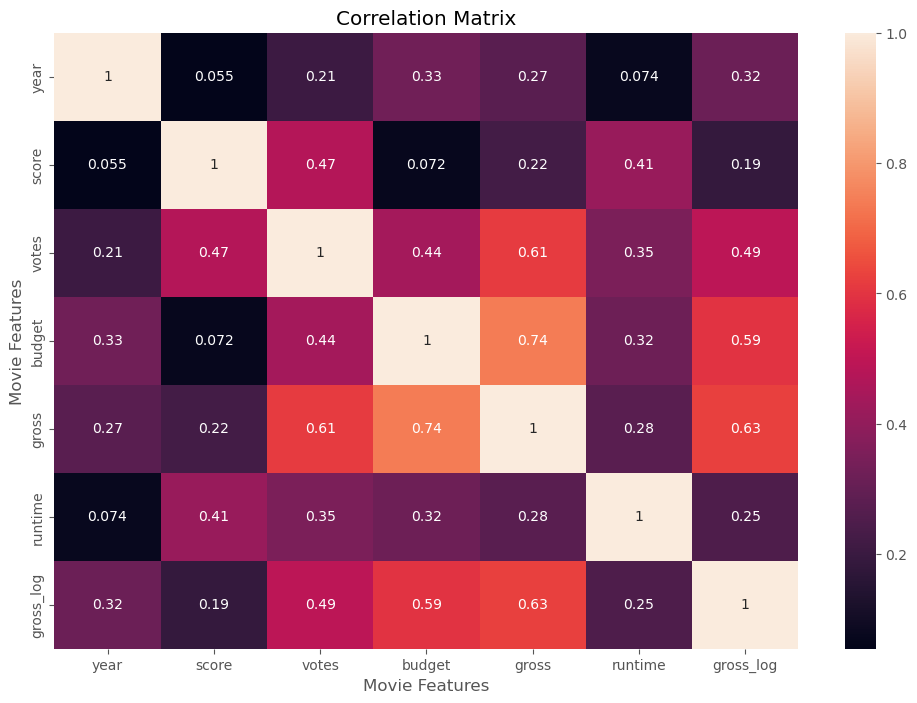

In [75]:
# The heatmap represents the correlation matrix of movie features,
# highlighting that budget and votes have strong positive relationships with gross revenue,
# while score and runtime show weaker correlations, indicating limited impact on earnings
correlation_matrix =df.corr(method ='pearson', numeric_only = True)
sns.heatmap(correlation_matrix,  annot = True)
plt.title('Correlation Matrix')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
plt.show()

In [77]:
# All categorical variables are converted into numerical codes using factorization,
# enabling correlation analysis across the entire dataset.
# This helps explore relationships between both numerical and categorical features,
# although interpretations for encoded categories should be made with caution
df_numerized =df 
for col_name in df_numerized.columns:
    if(df_numerized[col_name].dtype == 'object'):
        df_numerized[col_name] = df_numerized[col_name].astype('category')
        df_numerized[col_name] = df_numerized[col_name].cat.codes
df_numerized
        

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,Year,gross_log
5445,387,5,0,2009,528,7.8,1100000.0,787,1265,1538,47,237000000.0,2.847246e+09,1388,162.0,7,9.454425
7445,389,5,0,2019,138,8.4,903000.0,106,515,1474,47,356000000.0,2.797501e+09,987,181.0,5,9.446770
3045,4923,5,6,1997,535,7.8,1100000.0,787,1265,1076,47,200000000.0,2.201647e+09,1388,194.0,7,9.342748
6663,3656,5,0,2015,530,7.8,876000.0,770,1810,357,47,245000000.0,2.069522e+09,949,138.0,7,9.315870
7244,390,5,0,2018,146,8.4,897000.0,106,515,1474,47,321000000.0,2.048360e+09,987,149.0,5,9.311406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2434,2981,5,0,1993,1471,4.5,1900.0,1810,3112,187,47,5000000.0,2.970000e+03,1382,97.0,11,3.472756
3681,1599,3,6,2000,1726,6.8,43000.0,954,1687,528,6,5000000.0,2.554000e+03,468,108.0,13,3.407221
272,2921,6,9,1982,1530,3.9,2300.0,263,55,1477,47,800000.0,2.270000e+03,584,85.0,12,3.356026
2417,2401,-1,6,1993,64,7.3,5100.0,23,1220,1687,26,11900000.0,5.960000e+02,492,134.0,5,2.775246


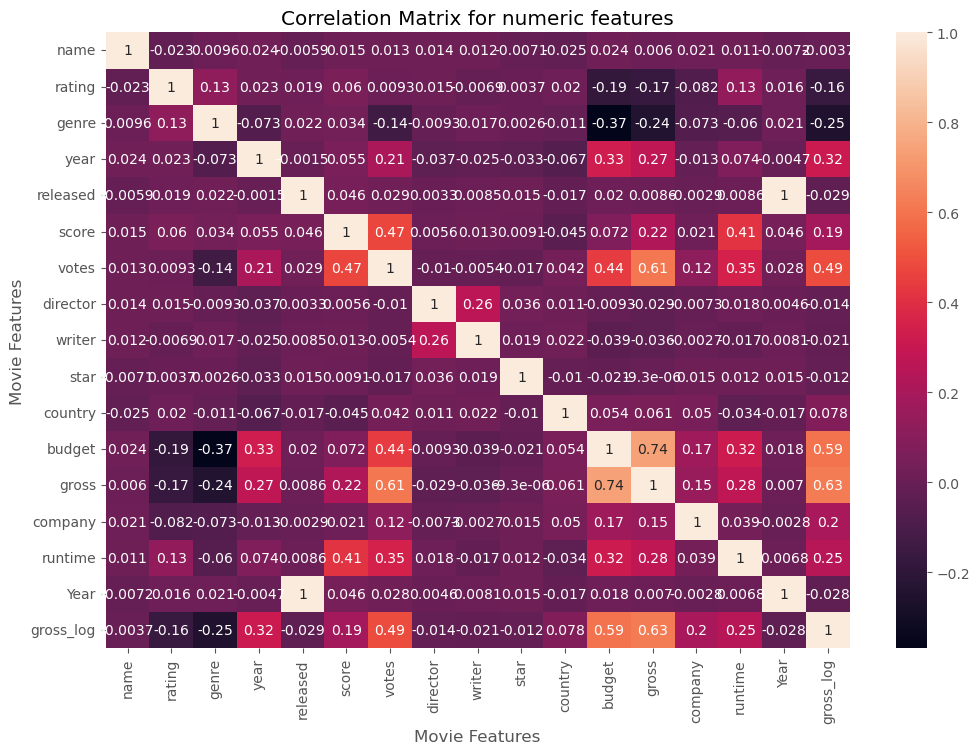

In [79]:
# The correlation heatmap shows relationships between numerical movie features,
# highlighting that budget and votes have strong positive correlations with gross revenue.
# In contrast, score, runtime, and year exhibit weaker relationships,
# indicating that investment and audience popularity are the key drivers of movie success
correlation_matrix =df_numerized.corr(method ='pearson', numeric_only = True)
sns.heatmap(correlation_matrix,  annot = True)
plt.title('Correlation Matrix for numeric features')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
plt.show()

In [81]:
# Encoding categorical variables into numeric values using factorization,
# then calculating and sorting correlation pairs to identify strong and weak relationships
# across all movie features, including previously non-numeric columns
correlation_mat = df.apply(lambda x: x.factorize()[0]).corr()

corr_pairs = correlation_mat.unstack()

print(corr_pairs)

name       name         1.000000
           rating       0.315672
           genre        0.186218
           year         0.266196
           released     0.667802
                          ...   
gross_log  gross        1.000000
           company      0.638592
           runtime      0.087448
           Year         0.145572
           gross_log    1.000000
Length: 289, dtype: float64


In [83]:
# Unstacking and sorting correlation values to easily identify strongest and weakest relationships
sorted_pairs = corr_pairs.sort_values(kind="quicksort")

print(sorted_pairs)

rating     score       -0.075083
score      rating      -0.075083
country    score       -0.056188
score      country     -0.056188
genre      country     -0.053820
                          ...   
year       year         1.000000
genre      genre        1.000000
rating     rating       1.000000
Year       Year         1.000000
gross_log  gross_log    1.000000
Length: 289, dtype: float64


In [85]:
# Filtering correlation pairs with absolute value greater than 0.5
# to identify strong relationships between movie features

strong_pairs = sorted_pairs[abs(sorted_pairs) > 0.5]

print(strong_pairs)

director   star         0.506157
star       director     0.506157
           writer       0.510510
writer     star         0.510510
           votes        0.523163
                          ...   
year       year         1.000000
genre      genre        1.000000
rating     rating       1.000000
Year       Year         1.000000
gross_log  gross_log    1.000000
Length: 79, dtype: float64


# Conclusion
#
# This analysis explored the key factors influencing movie box office performance.
# After cleaning and analyzing the dataset, several important insights were identified:
#
# - Budget has a strong positive relationship with gross revenue, indicating that higher investment generally leads to higher earnings.
#
# - Audience engagement, measured through votes, also shows a significant impact on revenue,suggesting that popularity plays a crucial role in movie success. 
#
# - Ratings (score) have a relatively weak correlation with gross revenue, indicating that critical reception alone does not guarantee financial success.
#
# - Genre and runtime show limited influence on earnings, while production companies demonstrate varying performance levels across years. 
#
# Overall, the analysis concludes that financial investment and audience reach are the primary drivers of box office success, rather than ratings alone.

### Project by Ankita Panwar